# EDA

In [1]:
# importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("/content/churn_dataset.csv")
data.head(10) # reading the data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
data.shape # data dimesnsions

(7043, 21)

## understaning data set features
- customerID : Unique ID assigned to each customer
- gender : Gender of the customer
- SeniorCitizen : 0 = Not senior citizen, 1 = Senior citizen
- Partner : Whether the customer has a partner (Yes/No)
- Dependents : Whether the customer has dependents (Yes/No)
- tenure : Number of months the customer has stayed with the company
- PhoneService : Whether the customer has phone service (Yes/No)
- MultipleLines : Whether the customer has multiple phone lines
- InternetService : Type of internet service (DSL/Fiber optic/No)
- OnlineSecurity : Whether online security service is active (Yes/No)
- OnlineBackup : Whether online backup service is active (Yes/No)
- DeviceProtection : Whether device protection service is active (Yes/No)
- TechSupport : Whether technical support service is active (Yes/No)
- StreamingTV : Whether streaming TV service is active (Yes/No)
- StreamingMovies : Whether streaming movies service is active (Yes/No)
- Contract : Type of contract (Month-to-month/One year/Two year)
- PaperlessBilling : Whether customer uses paperless billing (Yes/No)
- PaymentMethod : Method used for payment
- MonthlyCharges : Monthly amount charged to the customer
- TotalCharges : Total amount charged to the customer
- Churn : Whether the customer left the company (Yes/No)

In [4]:
data.info() # null values check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data['TotalCharges']=data['TotalCharges'].replace('\s+',np.nan,regex=True)
data['TotalCharges']=data['TotalCharges'].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_213/1251079721.py:1: SyntaxWarning: invalid escape sequence '\s'
  data['TotalCharges']=data['TotalCharges'].replace('\s+',np.nan,regex=True)


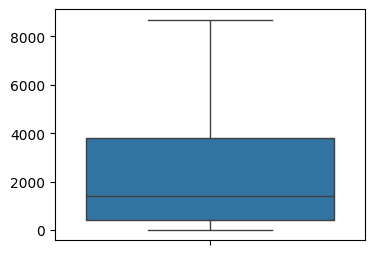

In [6]:
plt.figure(figsize=(4,3))
sns.boxplot(data['TotalCharges'].values) # outlier check
plt.show()

In [7]:
data['TotalCharges'].fillna(data['tenure']*data['MonthlyCharges'],inplace=True) # filling null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/tmp/ipykernel_213/370833712.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['tenure']*data['MonthlyCharges'],inplace=True) # filling null values


In [8]:
data.drop(columns='customerID',axis=1,inplace=True) # dropping customerID column
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [9]:
num_cols=['tenure','MonthlyCharges','TotalCharges']
cat_cols=['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
          'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']

## understanding distributions of features

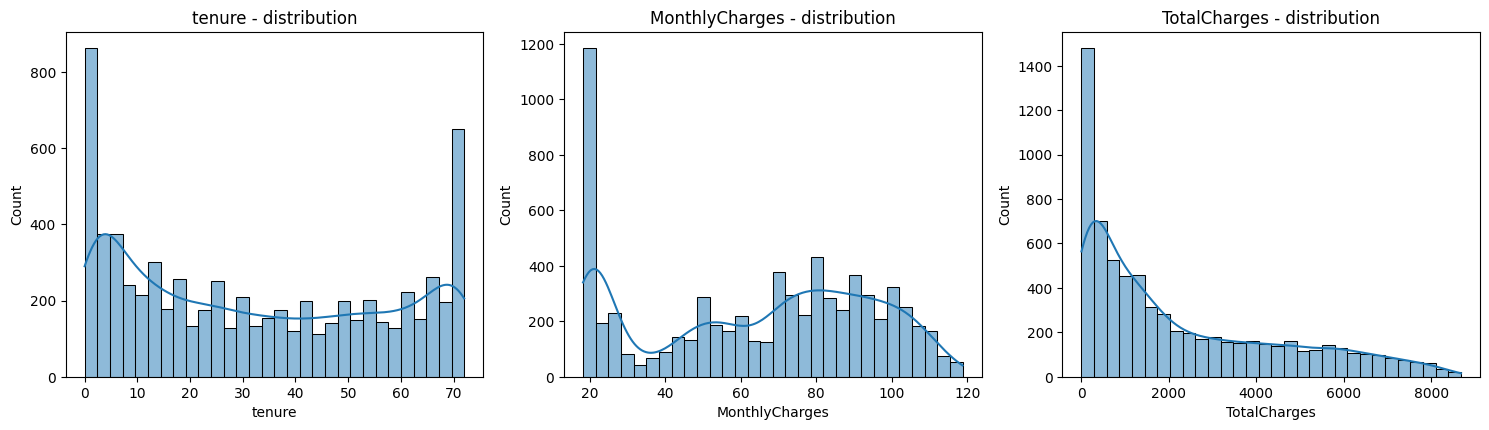

In [10]:
n_cols=3 # how many plots per row
n_rows=int(len(num_cols)/n_cols) + 1

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(data[col],bins=30,kde=True)
    plt.title(f'{col} - distribution')

plt.tight_layout()
plt.show()

## insights - numerical columns
- The distribution is heavily concentrated at very low tenure (0–5 months), indicating many customers are either new or churn early
- Monthly charges show a bimodal pattern, with peaks around lower (20–30) and mid-to-high (70–100) ranges
- Total charges are highly right-skewed, meaning most customers have low cumulative spending, while long-tenure customers accumulate very high total charges

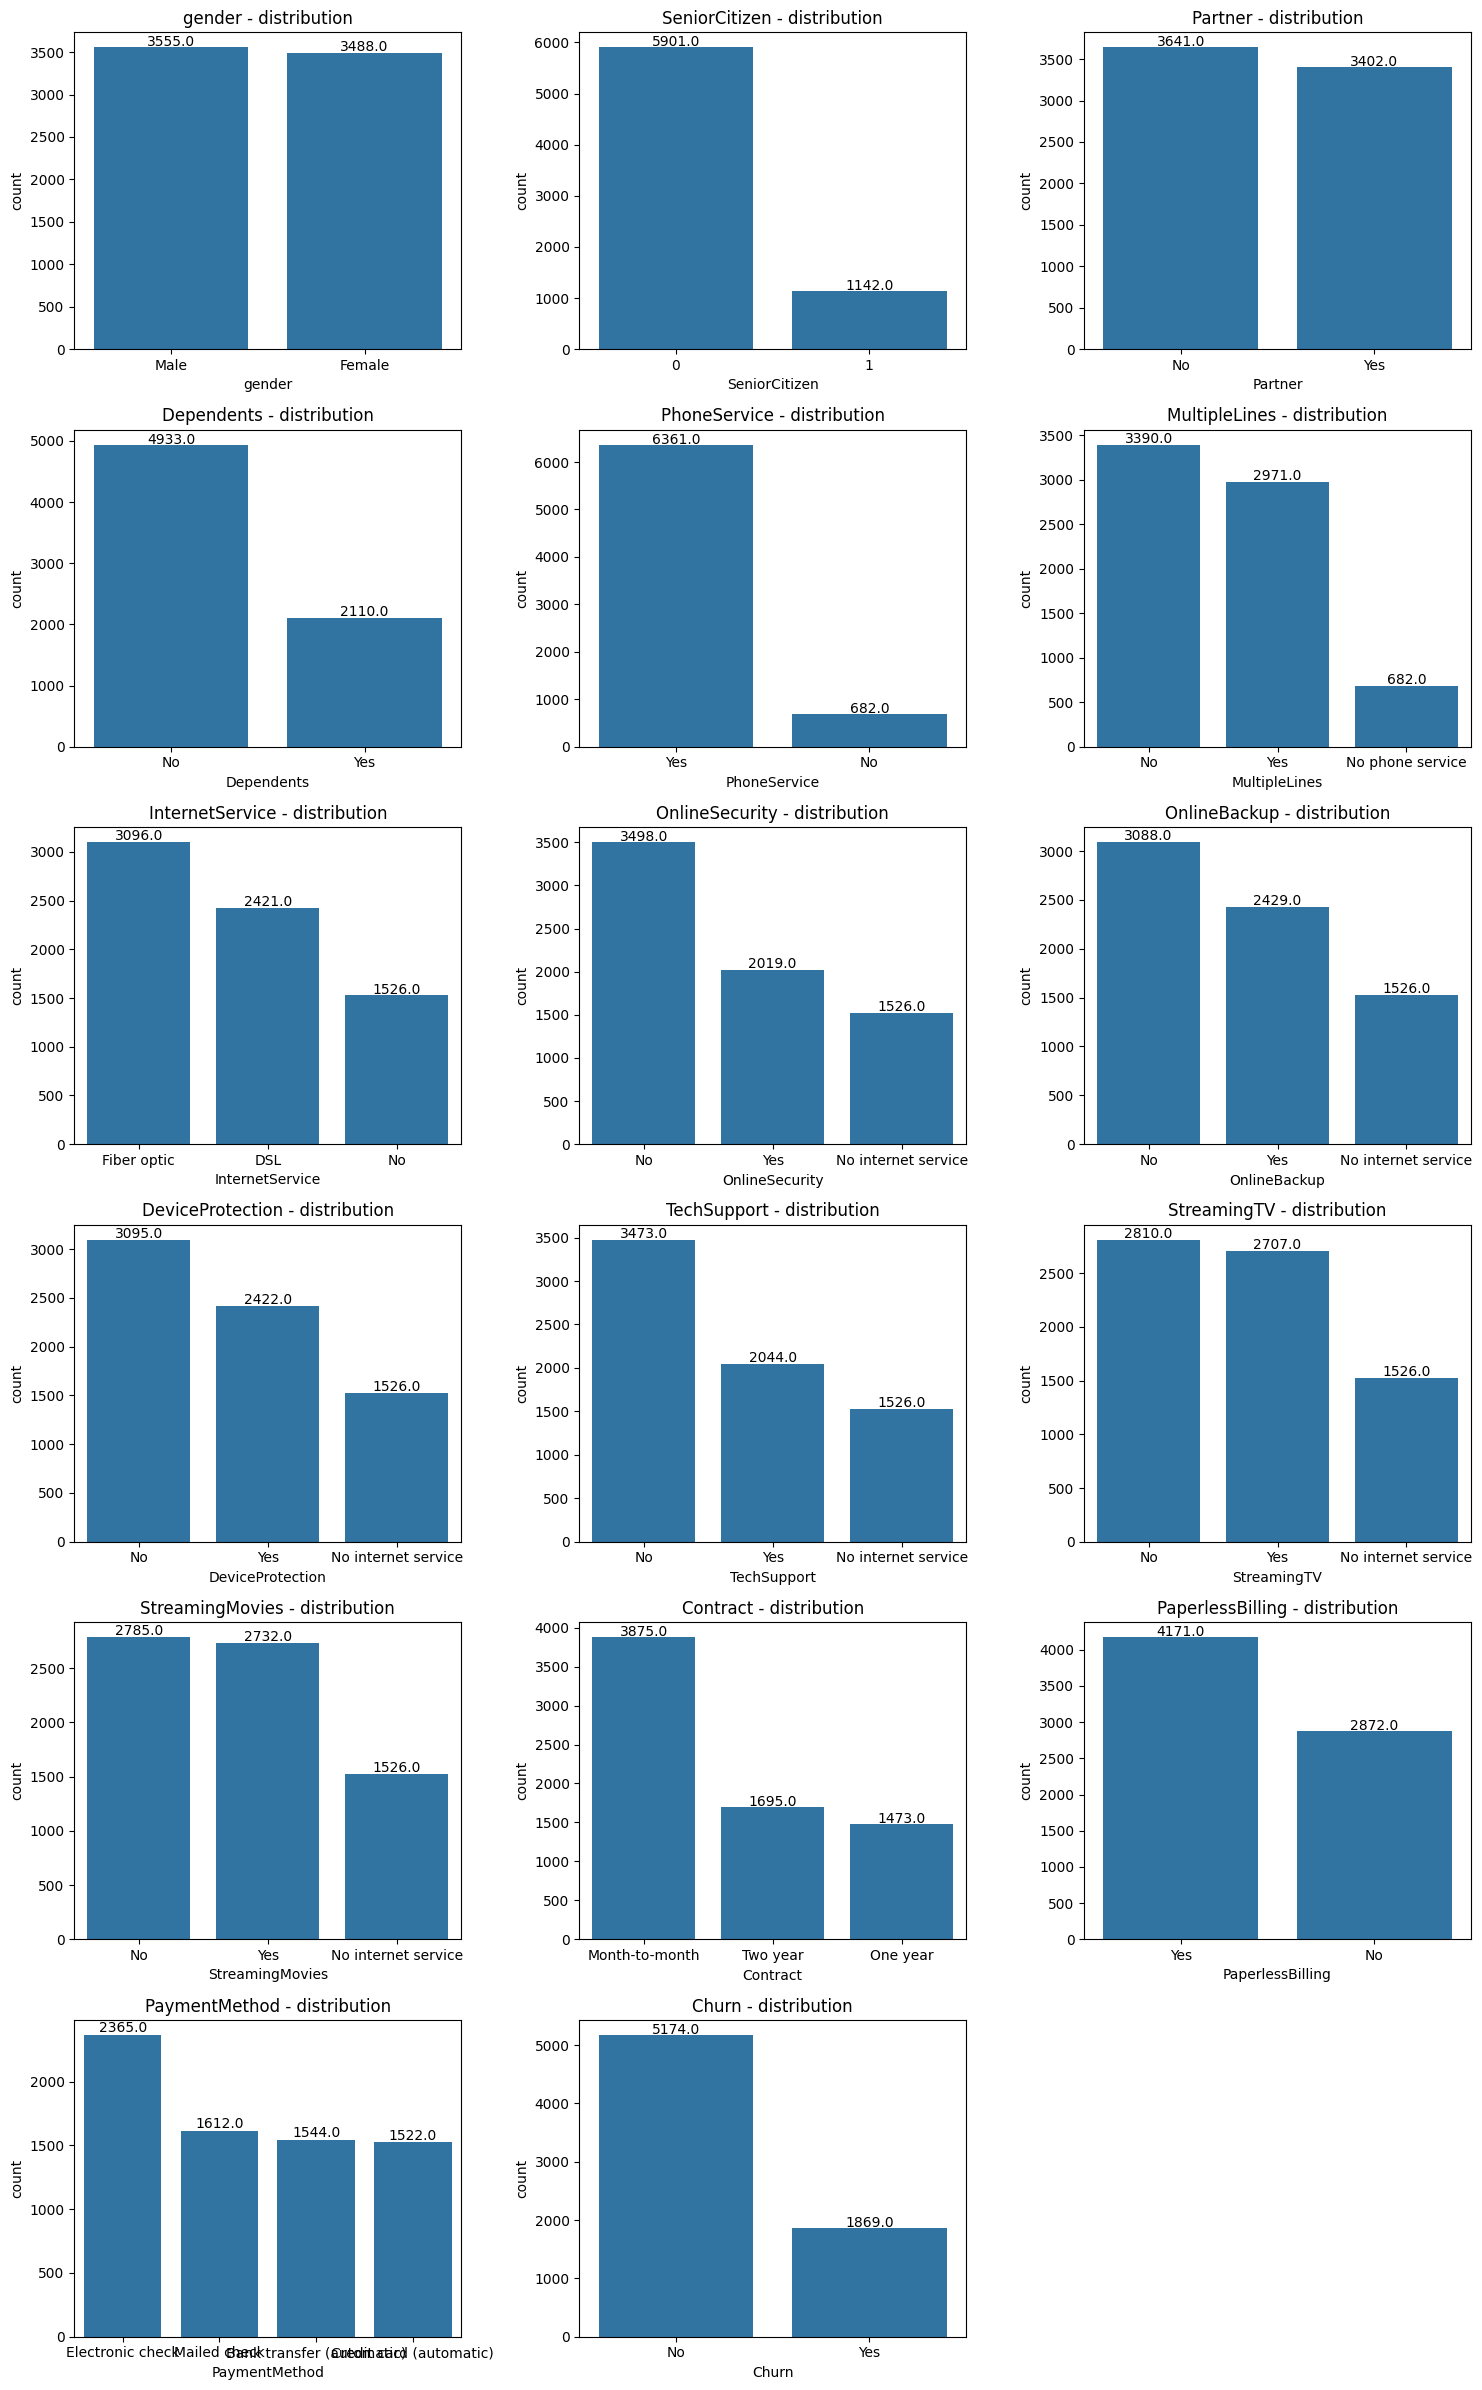

In [11]:
n_cols=3 # how many plots per row
n_rows=int(len(cat_cols)/n_cols) + 1

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.barplot(data[col].value_counts())
    plt.title(f'{col} - distribution')
    for p in plt.gca().patches:
        height = p.get_height()
        plt.text(p.get_x() + p.get_width()/2,height +20 ,f'{height}',ha='center')

plt.tight_layout()
plt.show()

## insights cat columns:

- Gender distribution is nearly balanced, indicating no strong gender dominance in the customer base.
- SeniorCitizen distribution shows a large majority of non-senior customers, meaning the dataset is skewed toward younger users.
- Partner distribution is fairly balanced, with a slightly higher number of customers without partners.
- Dependents distribution shows most customers do not have dependents, suggesting fewer family-based subscriptions.
- PhoneService distribution indicates almost all customers have phone service, making it a near-constant feature.
- MultipleLines distribution shows most customers either have a single line or multiple lines, with a small group having no phone service.
- InternetService distribution shows Fiber optic is the most common service, followed by DSL, with a smaller segment having no internet.
- OnlineSecurity distribution indicates a majority of customers do not have online security enabled.
- OnlineBackup distribution shows more customers lack backup services than those who use them.
- DeviceProtection distribution suggests most customers do not opt for device protection services.
- TechSupport distribution shows a higher number of customers without technical support subscriptions.
- StreamingTV distribution is fairly balanced between users and non-users, excluding those without internet service.
- StreamingMovies distribution is also balanced, indicating moderate adoption of streaming services.
- Contract distribution reveals that most customers are on month-to-month contracts, which typically increases churn risk.
- PaperlessBilling distribution shows a majority of customers prefer paperless billing.
- PaymentMethod distribution indicates Electronic check is the most commonly used payment method.
- Churn distribution is imbalanced, with significantly more customers staying than leaving.

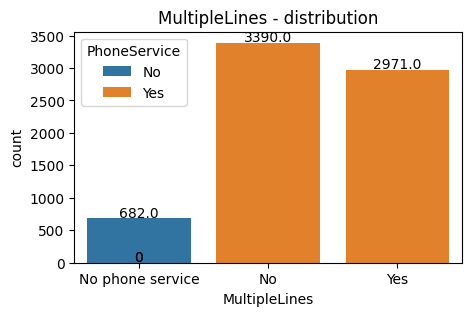

In [12]:
## multiple lines vs phone service:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x='MultipleLines', hue='PhoneService')
plt.title('MultipleLines - distribution')
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2,height +20 ,str(height),ha='center')
plt.show()

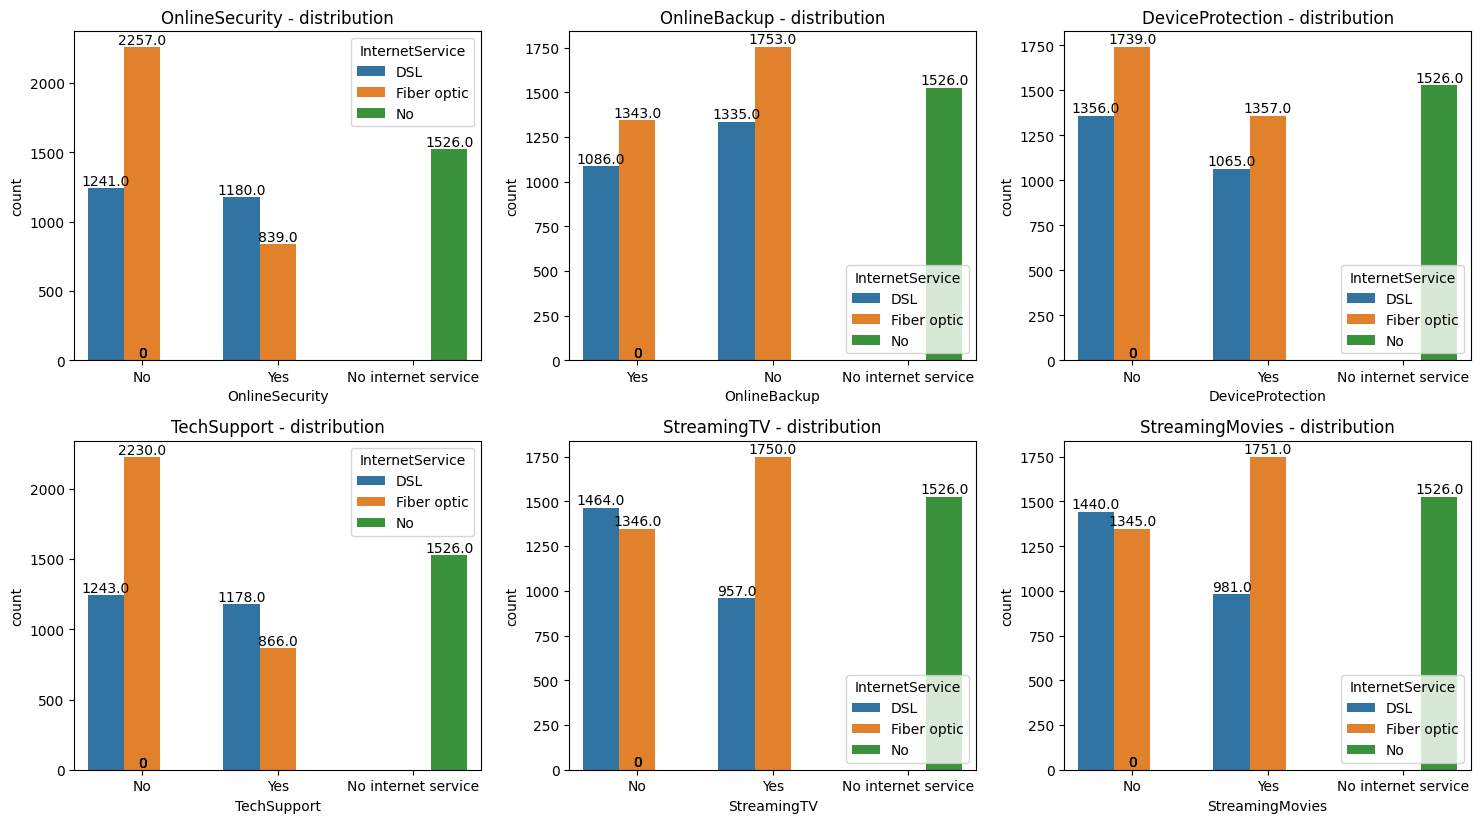

In [13]:
## internet service vs ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
lst=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

n_cols=3
n_rows= int(len(lst)/n_cols)+1

plt.figure(figsize=(15, 4 * n_rows))

for i,col in enumerate(lst):
    plt.subplot(n_rows,n_cols,i+1)
    sns.countplot(data=data, x=col, hue='InternetService')
    plt.title(f'{col} - distribution')
    for p in plt.gca().patches:
        height = p.get_height()
        plt.text(p.get_x()+p.get_width()/2,height +20 ,str(height),ha='center')

plt.tight_layout()
plt.show()


## insights on internet types
- OnlineSecurity distribution shows that Fiber optic users are more likely to not have online security compared to DSL users, indicating potential upselling opportunity and higher churn risk.
- OnlineBackup distribution indicates a majority of customers (especially Fiber optic users) do not subscribe to backup services.
- DeviceProtection distribution shows more customers opt out of device protection, particularly among Fiber optic users.
- TechSupport distribution reveals that most customers, especially Fiber optic users, do not take technical support services.
- StreamingTV distribution shows Fiber optic users are more likely to subscribe to streaming TV compared to DSL users.
- StreamingMovies distribution similarly indicates higher streaming adoption among Fiber optic customers than DSL users


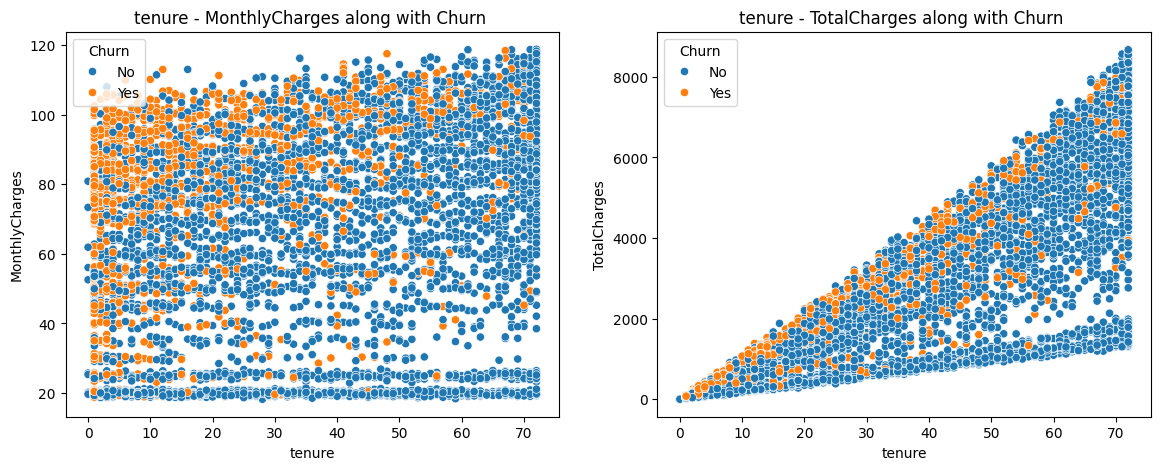

In [14]:
## visulaizing each feature with churn:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.scatterplot(data=data, x='tenure', y='MonthlyCharges', hue='Churn')
plt.title('tenure - MonthlyCharges along with Churn ')

plt.subplot(1,2,2)
sns.scatterplot(data=data, x='tenure', y='TotalCharges', hue='Churn')
plt.title('tenure - TotalCharges along with Churn ')

plt.show()

## insights Churn vs num cols:
- customers with high tenure and low monthly rate doesn't churn
- similarly customers with low tenure and high monthly charges tend to churn more

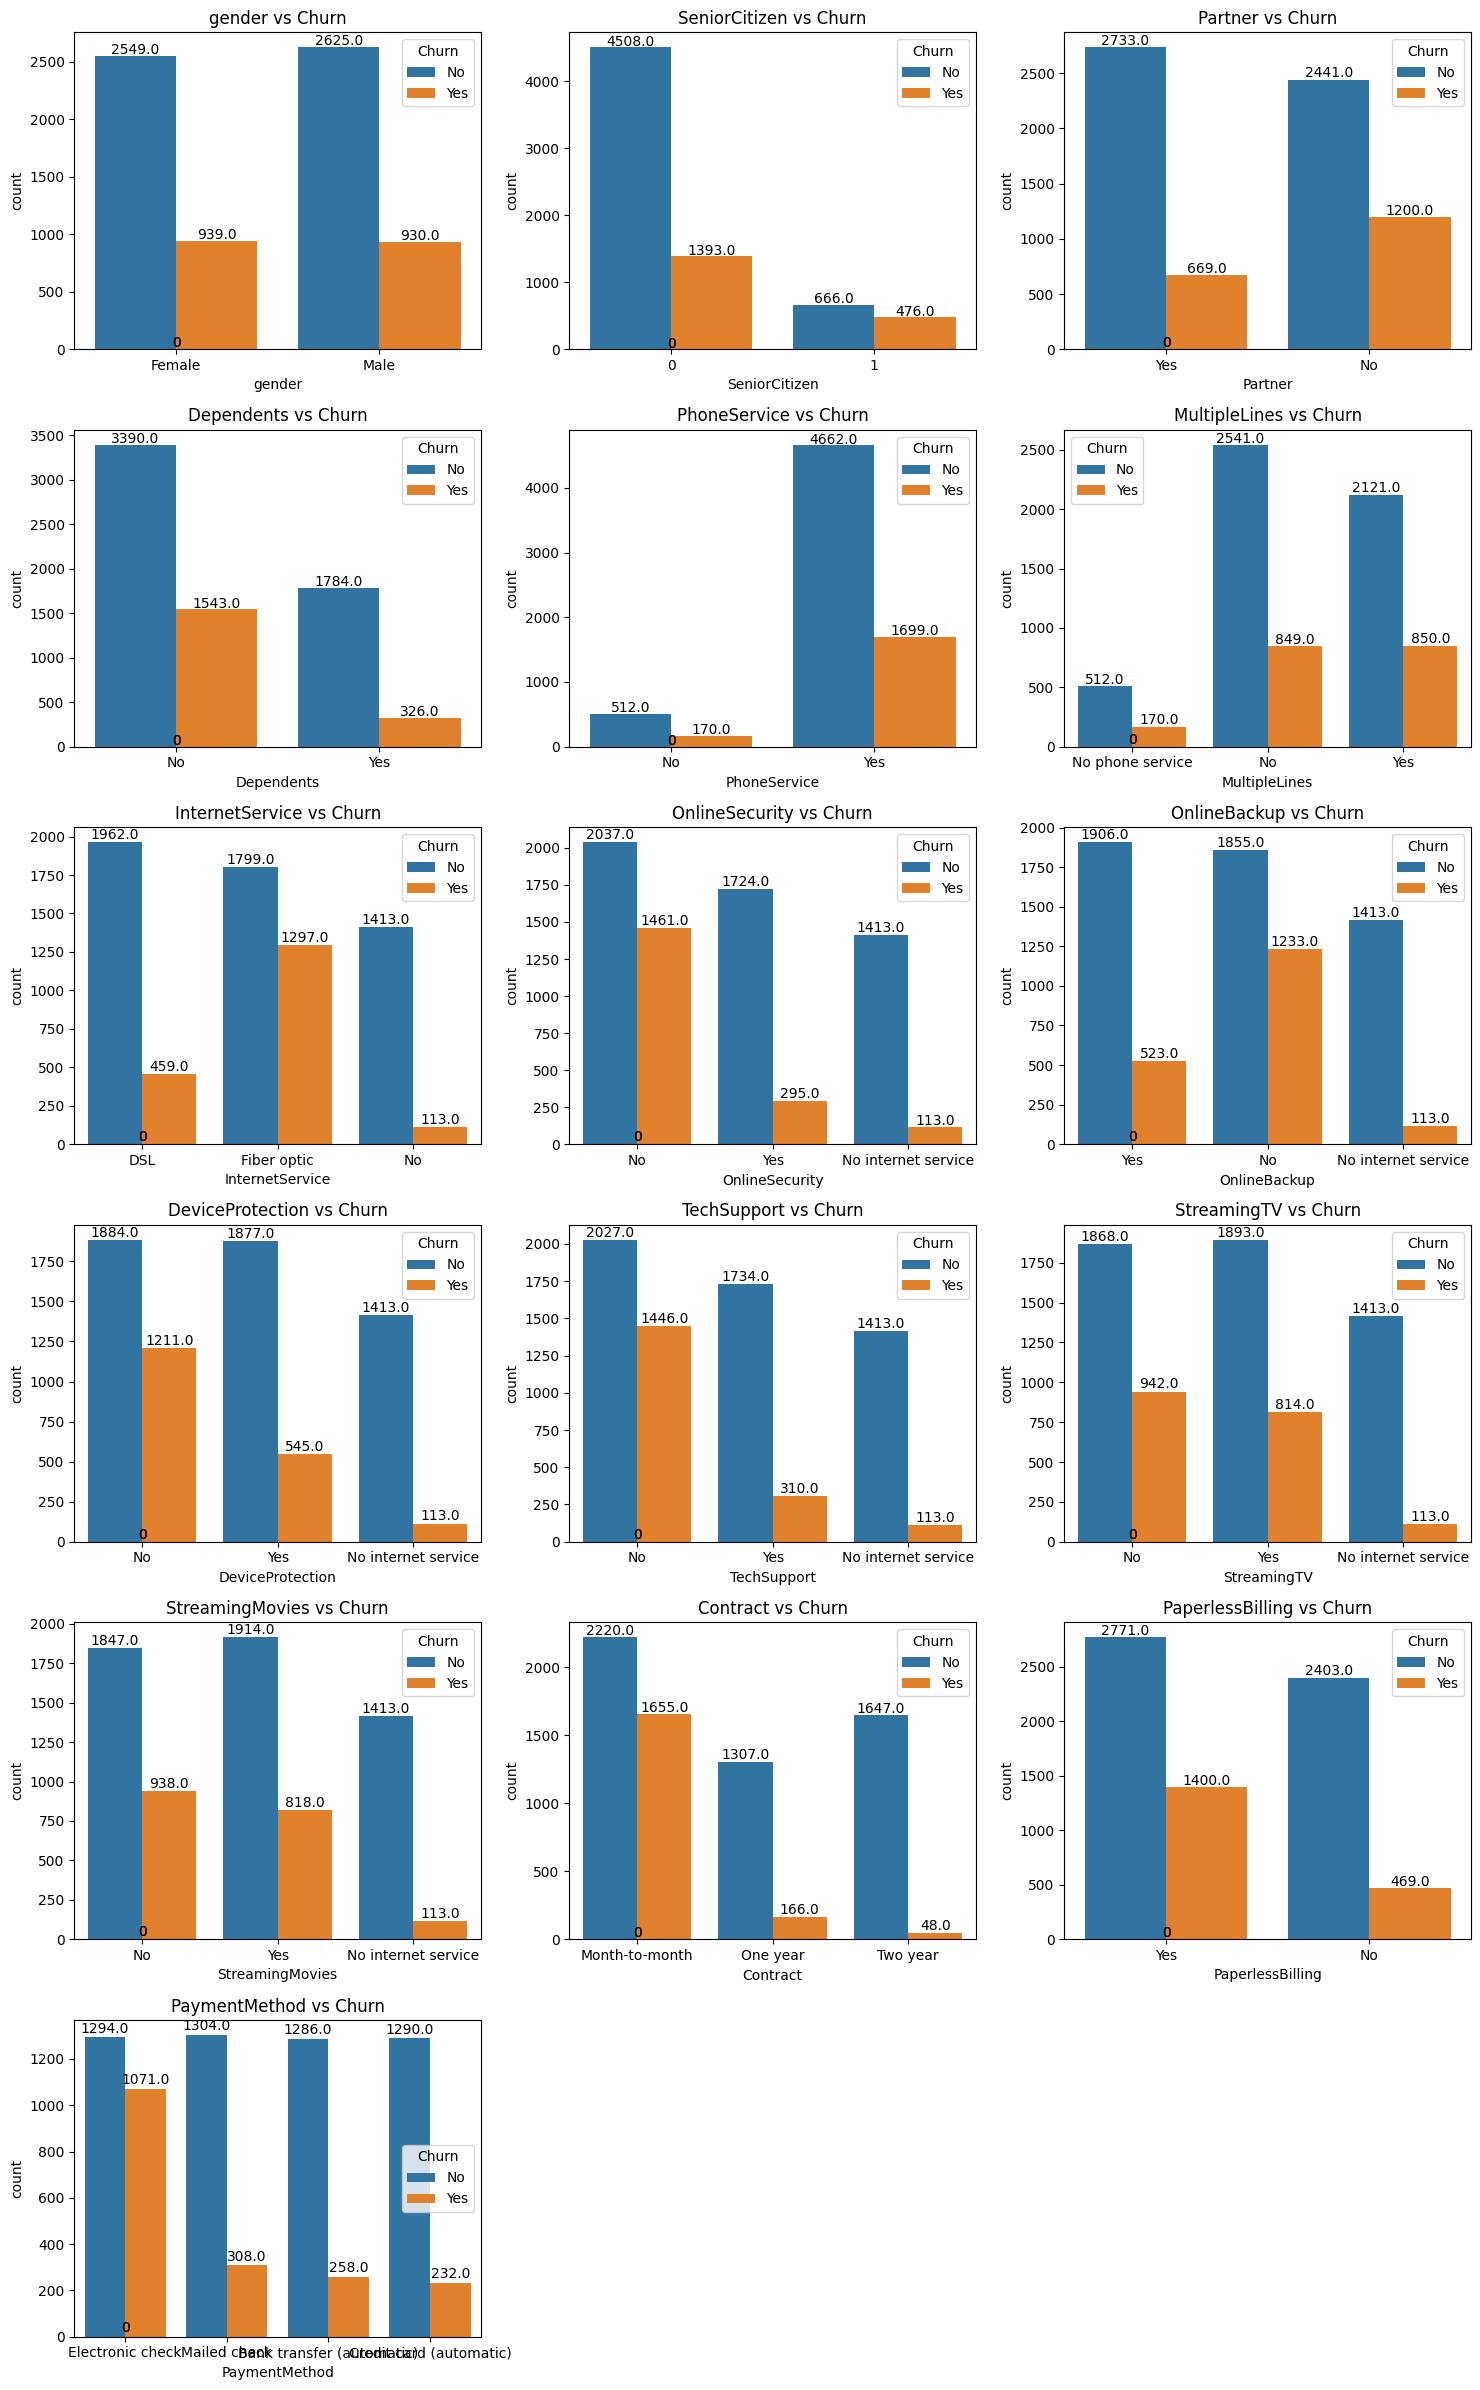

In [15]:
n_cols=3 # how many plots per row
n_rows=int(len(cat_cols[:-1])/n_cols) + 1

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cat_cols[:-1]):
    plt.subplot(n_rows,n_cols,i+1)
    sns.countplot(data=data,x=col,hue='Churn')
    plt.title(f'{col} vs Churn')
    for p in plt.gca().patches:
        height = p.get_height()
        plt.text(p.get_x() + p.get_width()/2,height +20 ,f'{height}',ha='center')

plt.tight_layout()
plt.show()

## insights churn vs cat cols:
- features gender, senior citizen, partner, MultipleLines, Streaming Tv, Streaming movies have no significant effect on churn.
- customers with no dependents have churned more than customers with dependents
- Fibre optic internet service customers churned in greater number than DSL customers.
- customers with no online security, no online backup, no device protection, no tech support have churned in greater numbers.
- month to month contract custoemrs have the tendency to churn
- Electronic check as payment method have churned more.


In [16]:
data['PaymentMethod'].groupby(data['Churn']).value_counts()

Churn  PaymentMethod            
No     Mailed check                 1304
       Electronic check             1294
       Credit card (automatic)      1290
       Bank transfer (automatic)    1286
Yes    Electronic check             1071
       Mailed check                  308
       Bank transfer (automatic)     258
       Credit card (automatic)       232
Name: count, dtype: int64

## important bussiness recommendations and conclusions: (After EDA)
- selling plans or services with low monthly charges and for higher tenure has the potential to retain the customers and reduce the Churn.
- fibre optic internet customers have churned more than DSL internet customers
partner with any DSL company and offer a small discount to customers who register with DSL instead of fibre optic
- customers with no online security, no online backup, no device protection, no tech support have churned in greater numbers
- Most importantly market and provide online security, online backup, device protection and tech support to customers this has the potential to significantly lower the customer churn
- since momth to month contract customers have churn tendency try to curate contracts than removes month to month or promote a month to month customers to eventually change to yearly.
- customers with eletronic check as payment method have churned more which indicates there might be inconvinence to customers with the payment method either address the problem with support from tech team or remove the paymet type and promote the rest payment types.

# Model

In [17]:
## importing necessary libraries:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [18]:
# data:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## outlier detection:

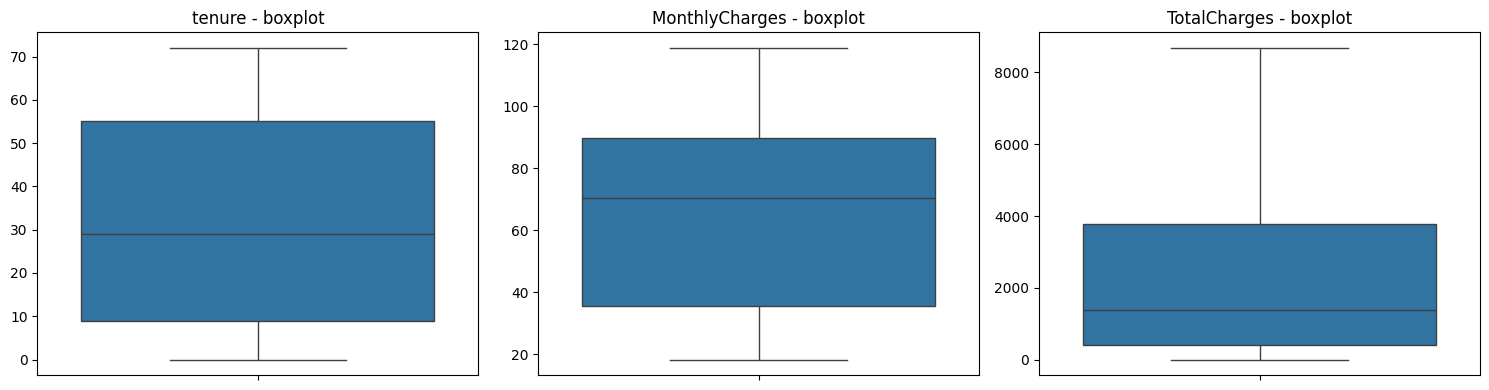

In [19]:
# outlier detection for num cols:

plt.figure(figsize=(15,4))
for i,col in enumerate(num_cols):

  plt.subplot(1,3,i+1)
  sns.boxplot(data[col].values)
  plt.title(f'{col} - boxplot')
plt.tight_layout()
plt.show()


In [20]:
# frequencies of values in cat cols:

for col in cat_cols:
  print(f'{col} - frequency')
  print(data[col].value_counts())
  print('-'*100)

gender - frequency
gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
SeniorCitizen - frequency
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Partner - frequency
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Dependents - frequency
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
PhoneService - frequency
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
MultipleLines - frequency
MultipleLines
No                  3390
Yes         

## manual encoding (preprocessing)

In [21]:
# binary cols encoding:

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in binary_cols:
  data[col] = data[col].map({'Yes':1,'No':0,'Female':0,'Male':1})

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [22]:
# ordinal cols encoding:

data['Contract']=data['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,0,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,1,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,0,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,0,1,Electronic check,70.70,151.65,1


## data splitting and nominal cols encoding

In [23]:
# data splitting and Nominal cols encoding:

X=data.drop(columns='Churn',axis=1)
y=data['Churn']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0,stratify=y)

In [24]:
nominal_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies','PaymentMethod']
encoder=ColumnTransformer(transformers=[('encoder',OneHotEncoder(drop='first'),nominal_cols)],remainder='passthrough')

X_train_encoded=encoder.fit_transform(X_train)
X_test_encoded=encoder.transform(X_test)

In [25]:
feature_names=encoder.get_feature_names_out()

X_train_encoded=pd.DataFrame(X_train_encoded,columns=feature_names)
X_test_encoded=pd.DataFrame(X_test_encoded,columns=feature_names)

X_train_encoded.head()

,encoder__MultipleLines_No phone service,encoder__MultipleLines_Yes,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__OnlineSecurity_No internet service,encoder__OnlineSecurity_Yes,encoder__OnlineBackup_No internet service,encoder__OnlineBackup_Yes,encoder__DeviceProtection_No internet service,encoder__DeviceProtection_Yes,...,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__Contract,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,71.0,1.0,2.0,0.0,85.75,6223.80
1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,19.85,19.85
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,50.95,229.40
3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,50.0,1.0,1.0,1.0,19.85,943.10
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,56.0,1.0,1.0,1.0,100.55,5514.95


In [26]:
X_test_encoded.head()

,encoder__MultipleLines_No phone service,encoder__MultipleLines_Yes,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__OnlineSecurity_No internet service,encoder__OnlineSecurity_Yes,encoder__OnlineBackup_No internet service,encoder__OnlineBackup_Yes,encoder__DeviceProtection_No internet service,encoder__DeviceProtection_Yes,...,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__Contract,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,1.0,0.0,1.0,58.95,601.60
1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,27.0,1.0,0.0,1.0,19.40,529.80
2,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,72.0,1.0,2.0,1.0,20.70,1482.30
3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,45.0,1.0,2.0,0.0,19.20,903.70
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,3.0,1.0,0.0,1.0,50.50,147.75


## data scaling:

In [27]:
# scalling numeric cols

X_train_encoded_scaled=X_train_encoded.copy()
X_test_encoded_scaled=X_test_encoded.copy()

num_cols_encoded=['remainder__tenure','remainder__MonthlyCharges','remainder__TotalCharges']

scaler=StandardScaler()
X_train_encoded_scaled[num_cols_encoded]=scaler.fit_transform(X_train_encoded_scaled[num_cols_encoded])
X_test_encoded_scaled[num_cols_encoded]=scaler.transform(X_test_encoded_scaled[num_cols_encoded])

In [28]:
X_train_encoded_scaled.head()

,encoder__MultipleLines_No phone service,encoder__MultipleLines_Yes,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__OnlineSecurity_No internet service,encoder__OnlineSecurity_Yes,encoder__OnlineBackup_No internet service,encoder__OnlineBackup_Yes,encoder__DeviceProtection_No internet service,encoder__DeviceProtection_Yes,...,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__Contract,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.589131,1.0,2.0,0.0,0.710795,1.763709
1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,-1.272574,1.0,1.0,0.0,-1.477313,-0.991317
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.109048,0.0,0.0,1.0,-0.444685,-0.898261
3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.730620,1.0,1.0,1.0,-1.477313,-0.581324
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.975909,1.0,1.0,1.0,1.202206,1.448926


In [29]:
X_train_encoded.head()

,encoder__MultipleLines_No phone service,encoder__MultipleLines_Yes,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__OnlineSecurity_No internet service,encoder__OnlineSecurity_Yes,encoder__OnlineBackup_No internet service,encoder__OnlineBackup_Yes,encoder__DeviceProtection_No internet service,encoder__DeviceProtection_Yes,...,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__Contract,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,71.0,1.0,2.0,0.0,85.75,6223.80
1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,19.85,19.85
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,50.95,229.40
3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,50.0,1.0,1.0,1.0,19.85,943.10
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,56.0,1.0,1.0,1.0,100.55,5514.95


## flow of data preprocessing and model building approach:
- we have manually encoded binary and ordinal cols using map
- then we have split the data in X,y
- encoded the nominal col using one hot encoder and fit transform train and only transform test
- similarly made scaled train, test sets
- made unscaled train, test sets
- scaled data will be used for KNN, logistic, SVM
- unscaled data will be used for decision tree and random forests.

## KNN model building, feature selection and tuning:

In [30]:
# importing necessaries:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [31]:
knn1=KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train_encoded_scaled,y_train)

KNeighborsClassifier()

In [32]:
y_pred_knn1=knn1.predict(X_test_encoded_scaled)
knn1_accuracy=accuracy_score(y_test,y_pred_knn1)
print(f'KNN 1 accuracy: {knn1_accuracy*100:.2f} %')

KNN 1 accuracy: 76.26 %


In [33]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)

X_train_selected = selector.fit_transform(X_train_encoded_scaled, y_train)
X_test_selected = selector.transform(X_test_encoded_scaled)

selected_features = X_train_encoded_scaled.columns[selector.get_support()]
print(selected_features)

Index(['encoder__InternetService_Fiber optic', 'encoder__InternetService_No',
       'encoder__OnlineSecurity_No internet service',
       'encoder__OnlineSecurity_Yes',
       'encoder__OnlineBackup_No internet service',
       'encoder__DeviceProtection_No internet service',
       'encoder__TechSupport_No internet service', 'encoder__TechSupport_Yes',
       'encoder__StreamingTV_No internet service',
       'encoder__StreamingMovies_No internet service',
       'encoder__PaymentMethod_Credit card (automatic)',
       'encoder__PaymentMethod_Electronic check', 'remainder__SeniorCitizen',
       'remainder__Partner', 'remainder__Dependents', 'remainder__tenure',
       'remainder__Contract', 'remainder__PaperlessBilling',
       'remainder__MonthlyCharges', 'remainder__TotalCharges'],
      dtype='object')


In [34]:
knn2=KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_selected,y_train)

KNeighborsClassifier()

In [35]:
y_pred_knn2=knn2.predict(X_test_selected)
knn2_accuracy=accuracy_score(y_test,y_pred_knn2)
print(f'KNN 2 accuracy: {knn2_accuracy*100:.2f} %')

KNN 2 accuracy: 77.91 %


In [36]:
param_grid = {'n_neighbors': range(3,20,2),'weights': ['uniform','distance']}
knn=KNeighborsClassifier()
grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5,n_jobs=-1)
grid_knn.fit(X_train_selected, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': range(3, 20, 2),
                         'weights': ['uniform', 'distance']})

In [37]:
print(grid_knn.best_params_)

{'n_neighbors': 19, 'weights': 'uniform'}


In [38]:
knn_best=grid_knn.best_estimator_
knn_best.fit(X_train_selected,y_train)

KNeighborsClassifier(n_neighbors=19)

In [39]:
y_pred_knn_best=knn_best.predict(X_test_selected)
knn_best_accuracy=accuracy_score(y_test,y_pred_knn_best)
print(f'KNN best accuracy: {knn_best_accuracy*100:.2f} %')

KNN best accuracy: 78.59 %


In [40]:
knn_df=pd.DataFrame({'model':['KNN','KNN - features selected','KNN - tuned'],'accracy':[knn1_accuracy,knn2_accuracy,knn_best_accuracy]})
knn_df


,model,accracy
0,KNN,0.762635
1,KNN - features selected,0.779103
2,KNN - tuned,0.785917


## Logistic regression model building, feature selection and tuning:

In [41]:
# importing necessary
from sklearn.linear_model import LogisticRegression

In [42]:
lr1=LogisticRegression(penalty='l2',C=1,max_iter=1000) # without feature selection
lr1.fit(X_train_encoded_scaled,y_train)

LogisticRegression(C=1, max_iter=1000)

In [43]:
y_pred_lr1=lr1.predict(X_test_encoded_scaled)
lr1_accuracy=accuracy_score(y_test,y_pred_lr1)
print(f'LR 1 accuracy: {lr1_accuracy*100:.2f} %')

LR 1 accuracy: 79.27 %


In [44]:
lr2=LogisticRegression(penalty='l1',C=1,max_iter=1000,solver='liblinear') # with feature selection
lr2.fit(X_train_encoded_scaled,y_train)

LogisticRegression(C=1, max_iter=1000, penalty='l1', solver='liblinear')

In [45]:
y_pred_lr2=lr2.predict(X_test_encoded_scaled)
lr2_accuracy=accuracy_score(y_test,y_pred_lr2)
print(f'LR 2 accuracy: {lr2_accuracy*100:.2f} %')

LR 2 accuracy: 79.10 %


In [46]:
# with selected feature(selectKbest,f_classif) and ridge regularization:
lr3=LogisticRegression(penalty='l2',C=1,max_iter=1000,solver='lbfgs')
lr3.fit(X_train_selected,y_train)

LogisticRegression(C=1, max_iter=1000)

In [47]:
y_pred_lr3=lr3.predict(X_test_selected)
lr3_accuracy=accuracy_score(y_test,y_pred_lr3)
print(f'LR 3 accuracy: {lr3_accuracy*100:.2f} %')

LR 3 accuracy: 79.16 %


In [48]:
## after feature selection accuracy dropped because it reduced overfitting as it reduced noise

In [49]:
param_grid={'C':[0.5,1,1.5,2],
            'max_iter':[800,900,1000,1100]}
lr=LogisticRegression()
grid_lr=GridSearchCV(estimator=lr,param_grid=param_grid,cv=5,n_jobs=-1)
grid_lr.fit(X_train_selected,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.5, 1, 1.5, 2],
                         'max_iter': [800, 900, 1000, 1100]})

In [50]:
print(grid_lr.best_params_)

{'C': 0.5, 'max_iter': 800}


In [51]:
lr_best=grid_lr.best_estimator_
lr_best.fit(X_train_selected,y_train)

LogisticRegression(C=0.5, max_iter=800)

In [52]:
y_pred_lr_best=lr_best.predict(X_test_selected)
lr_best_accuracy=accuracy_score(y_test,y_pred_lr_best)
print(f'LR best accuracy: {lr_best_accuracy*100:.2f}')

LR best accuracy: 79.27


In [53]:
lr_df=pd.DataFrame({'model':['LR','LR lasso','LR - features selected','LR - tuned'],'accracy':[lr1_accuracy,lr2_accuracy,lr3_accuracy,lr_best_accuracy]})
lr_df

,model,accracy
0,LR,0.792731
1,LR lasso,0.791028
2,LR - features selected,0.791596
3,LR - tuned,0.792731


## Support vector classifier model building, feature selection and tuning:

In [54]:
# importing necessary:
from sklearn.svm import SVC

In [55]:
svc1=SVC(kernel='rbf',C=1,gamma='scale',probability=True)
svc1.fit(X_train_encoded_scaled,y_train)

SVC(C=1, probability=True)

In [56]:
y_pred_svc1=svc1.predict(X_test_encoded_scaled)
svc1_accuracy=accuracy_score(y_test,y_pred_svc1)
print(f'SVC 1 accuracy: {svc1_accuracy*100:.2f} %')

SVC 1 accuracy: 79.05 %


In [57]:
svc2=SVC(kernel='rbf',C=1,gamma='scale',probability=True)
svc2.fit(X_train_selected,y_train)

SVC(C=1, probability=True)

In [58]:
y_pred_svc2=svc2.predict(X_test_selected)
svc2_accuracy=accuracy_score(y_test,y_pred_svc2)
print(f'SVC 2 accuracy: {svc2_accuracy*100:.2f} %')

SVC 2 accuracy: 78.93 %


In [59]:
param_grid={'kernel':['rbf'],
            'C':np.linspace(0.1,10,5),
            'gamma':['scale','auto']}
svc=SVC()
grid_svc=GridSearchCV(estimator=svc,param_grid=param_grid,cv=5,n_jobs=-1)
grid_svc.fit(X_train_selected,y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': array([ 0.1  ,  2.575,  5.05 ,  7.525, 10.   ]),
                         'gamma': ['scale', 'auto'], 'kernel': ['rbf']})

In [60]:
print(grid_svc.best_params_)

{'C': np.float64(7.525), 'gamma': 'scale', 'kernel': 'rbf'}


In [61]:
svc_best=grid_svc.best_estimator_
svc_best.fit(X_train_selected,y_train)

SVC(C=np.float64(7.525))

In [62]:
y_pred_svc_best=svc_best.predict(X_test_selected)
svc_best_accuracy=accuracy_score(y_test,y_pred_svc_best)
print(f'SVC best accuracy: {svc_best_accuracy*100:.2f} %')

SVC best accuracy: 78.99 %


In [63]:
svc_df=pd.DataFrame({'model':['SVC','SVC - features selected','SVC - tuned'],'accracy':[svc1_accuracy,svc2_accuracy,svc_best_accuracy]})
svc_df

,model,accracy
0,SVC,0.790460
1,SVC - features selected,0.789324
2,SVC - tuned,0.789892


## Decision tree classifier model building, feature selection and tuning:

In [64]:
# importing necessary:
from sklearn.tree import DecisionTreeClassifier

In [65]:
dt1=DecisionTreeClassifier(criterion='gini',max_depth=7,random_state=42)
dt1.fit(X_train_encoded,y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [66]:
y_pred_dt1=dt1.predict(X_test_encoded)
dt1_accuracy=accuracy_score(y_test,y_pred_dt1)
print(f'DT 1 accuracy: {dt1_accuracy*100:.2f} %')

DT 1 accuracy: 78.76 %


In [67]:
importances=dt1.feature_importances_
threshold=0.01
important_features=X_train_encoded.columns[importances>threshold]
print(important_features)

Index(['encoder__MultipleLines_Yes', 'encoder__InternetService_Fiber optic',
       'encoder__OnlineSecurity_No internet service',
       'encoder__OnlineSecurity_Yes', 'encoder__TechSupport_Yes',
       'encoder__StreamingMovies_Yes',
       'encoder__PaymentMethod_Electronic check', 'remainder__SeniorCitizen',
       'remainder__tenure', 'remainder__Contract',
       'remainder__PaperlessBilling', 'remainder__MonthlyCharges',
       'remainder__TotalCharges'],
      dtype='object')


In [68]:
X_train_selected_dt=X_train_encoded[important_features]
X_test_selected_dt=X_test_encoded[important_features]

In [69]:
dt2=DecisionTreeClassifier(criterion='gini',max_depth=7,random_state=42)
dt2.fit(X_train_selected_dt,y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [70]:
y_pred_dt2=dt2.predict(X_test_selected_dt)
dt2_accuracy=accuracy_score(y_test,y_pred_dt2)
print(f'DT 2 accuracy: {dt2_accuracy*100:.2f} %')

DT 2 accuracy: 78.82 %


In [71]:
param_grid={'criterion':['gini','entropy'],
            'max_depth':range(4,10)}
dt=DecisionTreeClassifier()
grid_dt=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,n_jobs=-1)
grid_dt.fit(X_train_selected_dt,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(4, 10)})

In [72]:
print(grid_dt.best_params_)

{'criterion': 'gini', 'max_depth': 4}


In [73]:
dt_best=grid_dt.best_estimator_
dt_best.fit(X_train_selected_dt,y_train)

DecisionTreeClassifier(max_depth=4)

In [74]:
y_pred_dt_best=dt_best.predict(X_test_selected_dt)
dt_best_accuracy=accuracy_score(y_test,y_pred_dt_best)
print(f'DT best accuracy: {dt_best_accuracy*100:.2f} %')

DT best accuracy: 79.44 %


In [75]:
dt_df=pd.DataFrame({'model':['DT','DT - features selected','DT - tuned'],'accracy':[dt1_accuracy,dt2_accuracy,dt_best_accuracy]})
dt_df

,model,accracy
0,DT,0.787621
1,DT - features selected,0.788189
2,DT - tuned,0.794435


## Random forest classifier model building,feature selection and tuning:

In [76]:
# importing necessary:
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf1=RandomForestClassifier(n_estimators=100,random_state=42)
rf1.fit(X_train_encoded,y_train)

RandomForestClassifier(random_state=42)

In [78]:
y_pred_rf1=rf1.predict(X_test_encoded)
rf1_accuracy=accuracy_score(y_test,y_pred_rf1)
print(f'RF 1 accuracy: {rf1_accuracy*100:.2f} %')

RF 1 accuracy: 78.99 %


In [79]:
importances=rf1.feature_importances_
threshold=0.01
important_features=X_train_encoded.columns[importances>threshold]
print(important_features)

Index(['encoder__MultipleLines_Yes', 'encoder__InternetService_Fiber optic',
       'encoder__OnlineSecurity_Yes', 'encoder__OnlineBackup_Yes',
       'encoder__DeviceProtection_Yes', 'encoder__TechSupport_Yes',
       'encoder__StreamingTV_Yes', 'encoder__StreamingMovies_Yes',
       'encoder__PaymentMethod_Credit card (automatic)',
       'encoder__PaymentMethod_Electronic check',
       'encoder__PaymentMethod_Mailed check', 'remainder__gender',
       'remainder__SeniorCitizen', 'remainder__Partner',
       'remainder__Dependents', 'remainder__tenure', 'remainder__Contract',
       'remainder__PaperlessBilling', 'remainder__MonthlyCharges',
       'remainder__TotalCharges'],
      dtype='object')


In [80]:
X_train_selected_rf=X_train_encoded[important_features]
X_test_selected_rf=X_test_encoded[important_features]

In [81]:
rf2=RandomForestClassifier(n_estimators=100,random_state=42)
rf2.fit(X_train_selected_rf,y_train)

RandomForestClassifier(random_state=42)

In [82]:
y_pred_rf2=rf2.predict(X_test_selected_rf)
rf2_accuracy=accuracy_score(y_test,y_pred_rf2)
print(f'RF 2 accuracy: {rf2_accuracy*100:.2f} %')

RF 2 accuracy: 79.39 %


In [83]:
param_grid={'n_estimators':[100,150,200,250,300]}
rf=RandomForestClassifier()
grid_rf=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,n_jobs=-1)
grid_rf.fit(X_train_selected_rf,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'n_estimators': [100, 150, 200, 250, 300]})

In [84]:
print(grid_rf.best_params_)

{'n_estimators': 300}


In [85]:
rf_best=grid_rf.best_estimator_
rf_best.fit(X_train_selected_rf,y_train)

RandomForestClassifier(n_estimators=300)

In [86]:
y_pred_rf_best=rf_best.predict(X_test_selected_rf)
rf_best_accuracy=accuracy_score(y_test,y_pred_rf_best)
print(f'RF best accuracy: {rf_best_accuracy*100:.2f} %')

RF best accuracy: 79.67 %


In [87]:
rf_df=pd.DataFrame({'model':['RF','RF - features selected','RF - tuned'],'accracy':[rf1_accuracy,rf2_accuracy,rf_best_accuracy]})
rf_df

,model,accracy
0,RF,0.789892
1,RF - features selected,0.793867
2,RF - tuned,0.796706


## model comparisions:

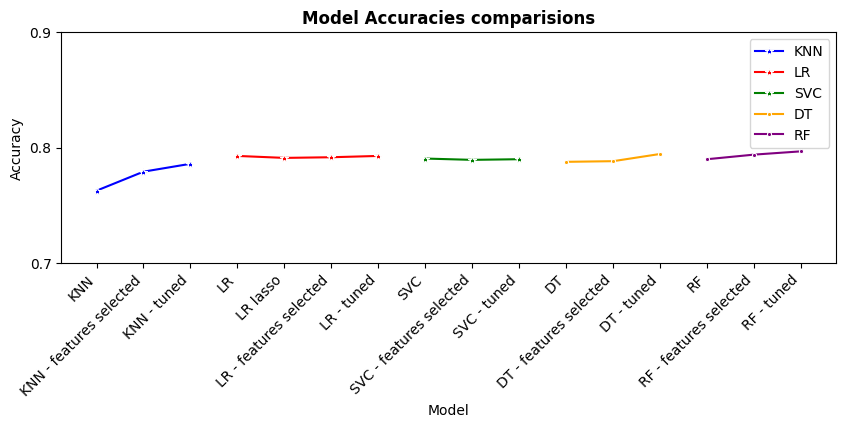

In [88]:
plt.figure(figsize=(10,3))
sns.lineplot(data=knn_df,x='model',y='accracy',marker='*',color='blue',label='KNN')
sns.lineplot(data=lr_df,x='model',y='accracy',marker='*',color='red',label='LR')
sns.lineplot(data=svc_df,x='model',y='accracy',marker='*',color='green',label='SVC')
sns.lineplot(data=dt_df,x='model',y='accracy',marker='.',color='orange',label='DT')
sns.lineplot(data=rf_df,x='model',y='accracy',marker='.',color='purple',label='RF')
plt.title('Model Accuracies comparisions',weight='bold')
plt.xticks(rotation=45,ha='right')
plt.yticks(np.arange(0.7,0.9,0.1))
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [89]:
from sklearn.metrics import classification_report,confusion_matrix

In [90]:
print('KNN :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_knn_best)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_knn_best)}')
print('-'*100)
print('LR :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_lr_best)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_lr_best)}')
print('-'*100)
print('SVC :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_svc_best)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_svc_best)}')
print('-'*100)
print('DT :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_dt_best)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_dt_best)}')
print('-'*100)
print('RF :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_rf_best)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_rf_best)}')

KNN :

Confusion matrix: 
[[1131  163]
 [ 214  253]]

Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1294
           1       0.61      0.54      0.57       467

    accuracy                           0.79      1761
   macro avg       0.72      0.71      0.72      1761
weighted avg       0.78      0.79      0.78      1761

----------------------------------------------------------------------------------------------------
LR :

Confusion matrix: 
[[1149  145]
 [ 220  247]]

Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1294
           1       0.63      0.53      0.58       467

    accuracy                           0.79      1761
   macro avg       0.73      0.71      0.72      1761
weighted avg       0.78      0.79      0.79      1761

------------------------------------------------------------------------------------------

## model comparision insights:
- RF tuned achieved highest accuracy of 79.67% among all the models
- Since DT, RF in general performed better on the data set it means that the data set behaviour is not linear so KNN, LR, SVC performed comparetively less than DT,RF
- since RF bundles mustiple DT together and considers their avg we can see slight improvemnet in RF tuned accuracy compared to DT tuned accuracy
- so we can conclude since churn dataset has complex customer behavior also has non linear relationships, RF performed better than other models.

## RF model insights:
- Class 0 (No Churn)
- Precision: 0.83
- Recall: 0.91
- F1-score: 0.87

- Class 1 (Churn)
- Precision: 0.66
- Recall: 0.49
- F1-score: 0.56

- model has strong performance in majority class and poor performance in minority class will address it since our focus will be mostly on predicting churn customers rather than non churn customers.
- The reason is pretty clear as the class imbalance is visible from class support

- 1175:	Correctly predicted non-churn	(TN)
- 119:	Predicted churn but actually stayed	(FP)
- 239:	Missed churn customers	(FN)
- 228:	Correctly predicted churn (TP)

In [92]:
# working on class imbalnce:
from imblearn.over_sampling import SMOTE

In [94]:
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train_selected_rf,y_train)

In [95]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Churn
0    3880
1    1402
Name: count, dtype: int64
Churn
0    3880
1    3880
Name: count, dtype: int64


In [96]:
rf_best_smote=grid_rf.best_estimator_
rf_best_smote.fit(X_train_smote,y_train_smote)

RandomForestClassifier(n_estimators=300)

In [98]:
y_pred_rf_best_smote=rf_best_smote.predict(X_test_selected_rf)
accuracy_rf_best_smote=accuracy_score(y_test,y_pred_rf_best_smote)
print(f'RF - Tuned, SMOTE accuracy: {accuracy_rf_best_smote*100:.2f} %')

RF - Tuned, SMOTE accuracy: 78.71 %


In [99]:
print('RF SMOTE :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_rf_best_smote)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_rf_best_smote)}')

RF SMOTE :

Confusion matrix: 
[[1156  138]
 [ 237  230]]

Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1294
           1       0.62      0.49      0.55       467

    accuracy                           0.79      1761
   macro avg       0.73      0.69      0.71      1761
weighted avg       0.78      0.79      0.78      1761



## RF - SMOTE insights:
- SMOTE technique didn't add any meaningfull data as a result we can see the model performance didn't get any better

In [100]:
# using class weights balanced:
rf_best_balanced=RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced')
rf_best_balanced.fit(X_train_selected_rf,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [101]:
y_pred_rf_best_balanced=rf_best_balanced.predict(X_test_selected_rf)
accuracy_rf_best_balanced=accuracy_score(y_test,y_pred_rf_best_balanced)
print(f'RF - Tuned, balanced accuracy: {accuracy_rf_best_balanced*100:.2f} %')

RF - Tuned, balanced accuracy: 79.61 %


In [102]:
print('RF Balanced :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_rf_best_balanced)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_rf_best_balanced)}')

RF Balanced :

Confusion matrix: 
[[1176  118]
 [ 241  226]]

Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1294
           1       0.66      0.48      0.56       467

    accuracy                           0.80      1761
   macro avg       0.74      0.70      0.71      1761
weighted avg       0.78      0.80      0.79      1761



## RF class weights balanced insights:
- model performace didn't improve any better

In [113]:
## adjusting prediction threshold:
y_proba=rf_best.predict_proba(X_test_selected_rf)[:,1]
threshold=0.35
y_pred_rf_best_adj=(y_proba>threshold).astype(int)

In [114]:
accuracy_rf_best_adj=accuracy_score(y_test,y_pred_rf_best_adj)
print(f'RF - Tuned, balanced accuracy: {accuracy_rf_best_adj*100:.2f} %')

RF - Tuned, balanced accuracy: 76.55 %


In [115]:
print('RF Proba Adjusted :\n')
print(f'Confusion matrix: \n{confusion_matrix(y_test,y_pred_rf_best_adj)}\n')
print(f'Classification report: \n{classification_report(y_test,y_pred_rf_best_adj)}')

RF Proba Adjusted :

Confusion matrix: 
[[1039  255]
 [ 158  309]]

Classification report: 
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1294
           1       0.55      0.66      0.60       467

    accuracy                           0.77      1761
   macro avg       0.71      0.73      0.72      1761
weighted avg       0.78      0.77      0.77      1761



## RF proba adjusted insights:
- Recall, f1-score of class 1 improved help our model perform better on churned customers which is more important in real world than performance on non churned customers.
- 66 % churn customers are identified after adjusting proba compared to previous 49 %

## over all conclusions after Model comparisions and class imbalance handling:

- Churn dataset is very dynamic since its based on customer behaviour which inturn has many categorical features
- in this case study we have successfully understood that customer churn behaviour is non linear
- Churn datasets usally have higher number of no churn customers than churned customers which will be challange to train our model
- in real world case study like this, recall of churned customers is very important than the model accuracy itself, since identifying the churned customers learning their behaviour is more important.  